# COOX Data Analytics : Non-Serviceable Bookings Analysis

The notebook analyzes booking data to identify patterns in non-serviceable locations.

Objective: Identify geographic clusters of non-serviceable bookings & create a pincode blocklist.

## Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from geopy.geocoders import Nominatim
from shapely.geometry import Point, MultiPoint
import time

In [2]:
# setting theme
sns.set_theme(style="whitegrid")

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Loading Dataset
df = pd.read_csv('Dataset_Coox.csv')


print('Overview')
print(f'Shape: {df.shape}')
print('Column Data Types:')
print(df.dtypes)
print()
print('Sample')
df.head()

Overview
Shape: (557, 10)
Column Data Types:
Booking ID          int64
Payment Status        str
Address ID          int64
Address Type          str
Area                  str
City                  str
State                 str
Country               str
Lat               float64
Long              float64
dtype: object

Sample


,Booking ID,Payment Status,Address ID,Address Type,Area,City,State,Country,Lat,Long
0,509103,refunded_full,152622,Home,byalalu village chunchanaguppe post,Bengaluru,Karnataka,India,12.897291,77.375508
1,700991,refunded_full,208569,Farmhouse,Outside Hyderabad,Hyderabad,Telangana,India,16.969071,78.518297
2,717282,refunded_full,216864,Office,"Aawasari Phata Manchar, Taluka Ambegaon, Mahar...",Pune,Maharashtra,India,18.979685,73.947376
3,717285,refunded_full,216864,Office,"Aawasari Phata Manchar, Taluka Ambegaon, Mahar...",Pune,Maharashtra,India,18.979685,73.947376
4,717290,refunded_full,216864,Office,"Aawasari Phata Manchar, Taluka Ambegaon, Mahar...",Pune,Maharashtra,India,18.979685,73.947376


In [5]:
# Check for null values
print("Null counts:")
print(df.isnull().sum())
print(f"percent null in Lat/Long: {df["Lat"].isnull().sum() / len(df) * 100:.2f} %")

Null counts:
Booking ID         0
Payment Status     0
Address ID         0
Address Type       6
Area               9
City               0
State              0
Country            0
Lat               11
Long              11
dtype: int64
percent null in Lat/Long: 1.97 %


In [6]:
# Refund check
print("Payment Status Distribution:")
print(df["Payment Status"].value_counts())
# Note all 557 records are refunded hence represents only non-serviceable bookings.

Payment Status Distribution:
Payment Status
refunded_full    557
Name: count, dtype: int64


## Exploratory Data Analysis

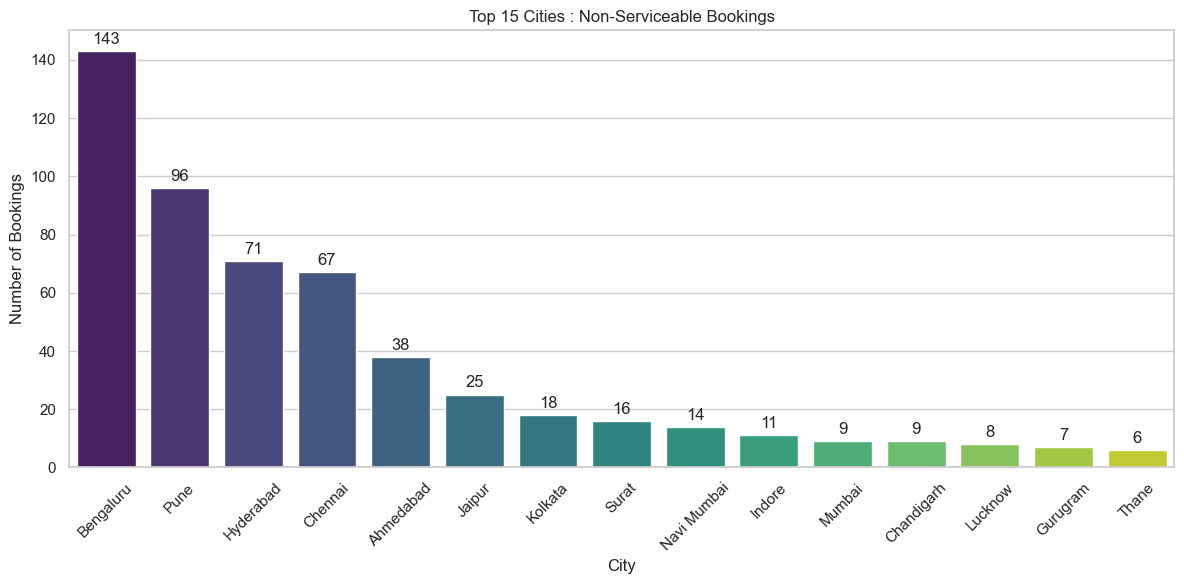

In [7]:
# City wise booking
top_cities = df["City"].value_counts().head(15) # top15


plt.figure(figsize=(12, 6))
cityplot = sns.barplot(x=top_cities.index, y=top_cities.values , palette="viridis")

# adding labels 
for container in cityplot.containers:
    cityplot.bar_label(container, padding=3)

plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Number of Bookings")
plt.title("Top 15 Cities : Non-Serviceable Bookings")
plt.tight_layout()
# plt.savefig("city_wise_bookings.png", dpi=150, bbox_inches="tight")
plt.show()


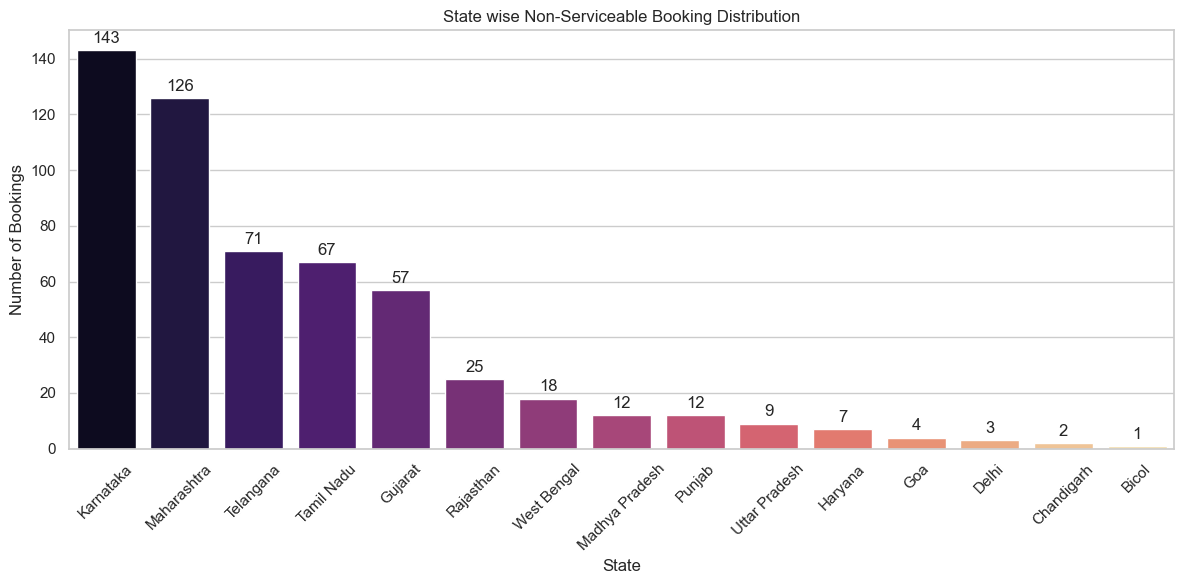

In [8]:
# State wise bookings
plt.figure(figsize=(12, 6))
states = df["State"].value_counts()

stateplot = sns.barplot(x=states.index, y=states.values, palette="magma")

for container in stateplot.containers:
    stateplot.bar_label(container, padding=3)

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Number of Bookings")
plt.title("State wise Non-Serviceable Booking Distribution")
plt.tight_layout()

# plt.savefig("state_wise_bookings.png", dpi=150, bbox_inches="tight")
plt.show()

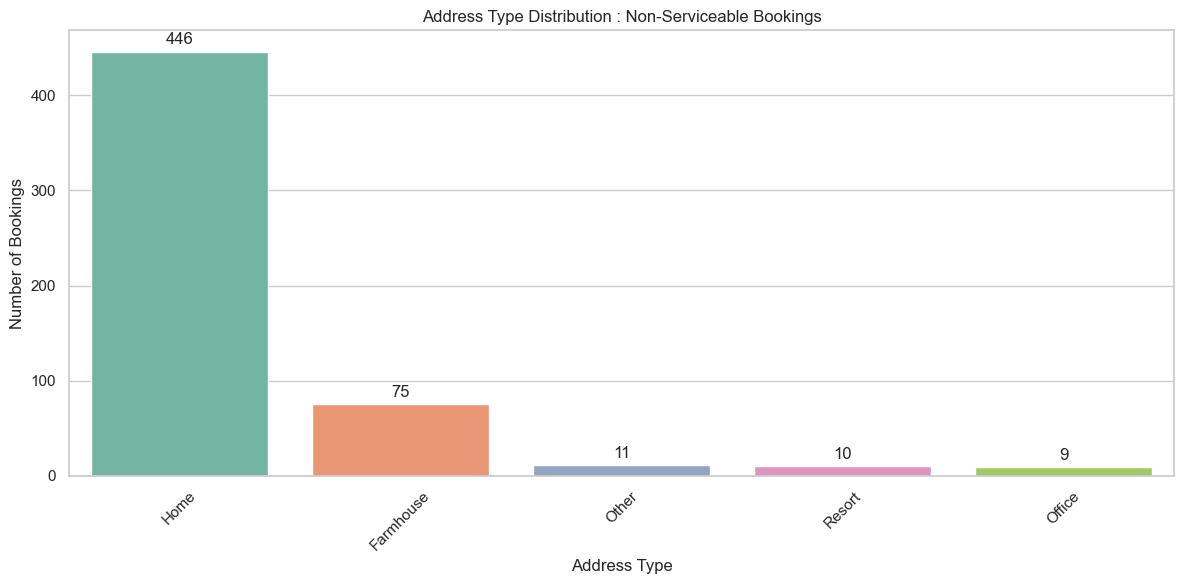

In [9]:
# Address Type distribution

plt.figure(figsize=(12, 6))


address_counts = df["Address Type"].value_counts()
addressplot= sns.barplot(x=address_counts.index, y=address_counts.values, palette="Set2")

for container in addressplot.containers:
    addressplot.bar_label(container, padding=3)

plt.xticks(rotation=45)
plt.xlabel("Address Type")
plt.ylabel("Number of Bookings")
plt.title("Address Type Distribution : Non-Serviceable Bookings")
plt.tight_layout()

# plt.savefig("address_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

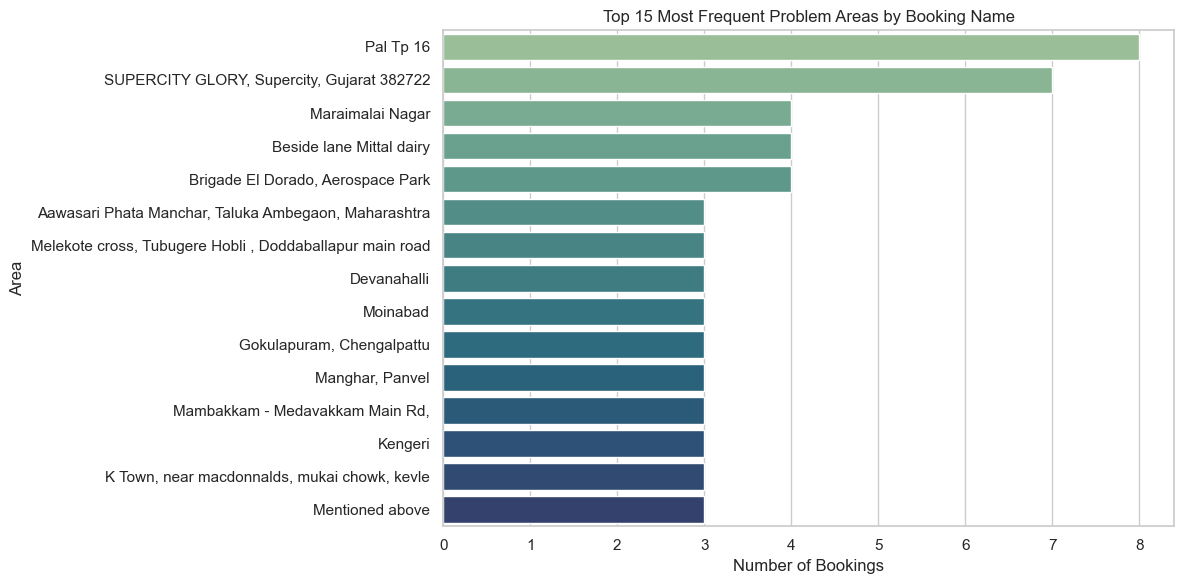

In [ ]:
# Top 15 most frequent problem areas

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

area_counts = df["Area"].value_counts().head(15)
areaplot = sns.barplot(x=area_counts.values, y=area_counts.index, palette="crest")


plt.xlabel("Number of Bookings")
plt.ylabel("Area")
plt.title("Top 15 Most Frequent Problem Areas by Booking Name")
plt.tight_layout()

# plt.savefig("top_problem_areas.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Handling null Lat/Long values
null_coords = df[df["Lat"].isnull() | df["Long"].isnull()]
valid_coords = df[df["Lat"].notnull() & df["Long"].notnull()]

print("Coordinate Data Quality")
print()
print("Total records: ", len(df))
print("Records with valid coordinates: ",len(valid_coords))
print("Records with missing coordinates:", len(null_coords))
print(f"Percentage of missing data: {len(null_coords) / len(df) * 100:.2f}%")
# Note 11 rows with null coordinates will be dropped for spatial analysis.

Coordinate Data Quality

Total records:  557
Records with valid coordinates:  546
Records with missing coordinates: 11
Percentage of missing data: 1.97%


## Geospatial Heatmap

In [ ]:
# Creating heatmap using folium


india_coords = [20.5937, 78.9629]
hm = folium.Map(location=india_coords, zoom_start=5, tiles=None)

# Preparing data (only valid coordinates)
coords_list = valid_coords[["Lat", "Long"]].values.tolist()
HeatMap(coords_list, radius=15, blur=20, max_zoom=10, min_opacity=0.4).add_to(hm)

# adding different maps
folium.TileLayer("https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}", attr="Esri", name="Satellite").add_to(hm)
folium.TileLayer("CartoDB positron", name="Light Mode").add_to(hm)
folium.TileLayer("CartoDB dark_matter", name="Dark Mode").add_to(hm)
folium.LayerControl().add_to(hm)


# hm.save("heatmap.html")
# heatmap saved 
hm

## Cluster Detection with DBSCAN

### Elbow method for best hyperparameter

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# finding the optimal epsilon
coords = np.radians(valid_coords[["Lat", "Long"]].values)
k = 3 

neighbors = NearestNeighbors(n_neighbors=k, metric="haversine")
neighbors.fit(coords)
distances, _ = neighbors.kneighbors(coords)

# getting the distance to kth neighbor and convert to km
kdistances = np.sort(distances[:, k-1])[::-1]
kdistanceskm = kdistances * 6371.0

# plotting
plt.figure(figsize=(10, 6))
plt.plot(kdistanceskm)

plt.xlabel("Points sorted by distance")
ylabel = str(k) + "th Nearest Neighbor Distance (km)"
plt.ylabel(ylabel)
plt.title("K-Distance Plot")

plt.axhline(y=2.0, color="red", linestyle="--", label="Chose epsilon 2km")
plt.legend()
# plt.savefig("k_distance_elbow.png", dpi=300, bbox_inches="tight")
plt.show()

### Epsilon Selection Balancing Math and Reality

While the K-Distance plot calculates the theoretical mathematical "elbow" at a much higher distance (approx. 15-20 km), I am intentionally overriding this with a business-constrained Epsilon of 2 km. 

Here is the logic for this decision:

* **Preventing Massive Revenue Loss (Over-blocking):** A 15 km radius covers huge sections of a city. Geoblocking such a large area based on a few failed deliveries would result in blocking hundreds of perfectly valid, highly profitable bookings.
* **Pin-Code Level Precision:** The primary objective is to extract specific, actionable problem pin codes. An average outskirts pin code aligns perfectly with a 2 km search radius (an area of roughly 12.5 sq km).
* **Capturing Farmhouse Outliers:** As seen in EDA, a significant portion of non-serviceable bookings are farmhouses or resorts. 2 km radius is just wide enough to group these spread-out properties into a single cluster without sweeping in the neighboring urban infrastructure.


In [12]:
coords = valid_coords[["Lat", "Long"]].values

# Epsilon is 2km to extract specific pin codes without over-blocking
epsilon = 2
epsilon_radians = epsilon / 6371.0 

# min_samples is 3 as the dataset is small &
# I want to catch small neighborhood hotspots even if there are only a few refunds
min_samples = 3

print("DBSCAN Parameters:")
print("Epsilon (km):", epsilon)
print("Min Samples:", min_samples)

db = DBSCAN(eps=epsilon_radians, min_samples=min_samples, metric="haversine", algorithm="ball_tree")
db.fit(np.radians(coords))

# making valid coord df to get clusters
valid_coords = valid_coords.copy()
valid_coords["cluster"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
total_clustered = len(db.labels_) - n_noise

print()
print("Clustering Results:")
print("Total clusters found:", n_clusters)
print("Noise points:", n_noise)
print("Total points clustered:", total_clustered)

DBSCAN Parameters:
Epsilon (km): 2
Min Samples: 3

Clustering Results:
Total clusters found: 53
Noise points: 319
Total points clustered: 227


In [13]:
# Generating cluster summary table
cluster_summary = []

for cluster_id in sorted(set(db.labels_)):
    if cluster_id == -1:
        continue 
    
    cluster_points = valid_coords[valid_coords["cluster"] == cluster_id]
    
    centroid_lat = cluster_points["Lat"].mean()
    centroid_lon = cluster_points["Long"].mean()
    
    cities = cluster_points["City"].unique().tolist()
    dominant_type = cluster_points["Address Type"].value_counts().idxmax()
    
    cluster_summary.append({
        "Cluster ID": cluster_id,
        "Size": len(cluster_points),
        "Centroid Lat": centroid_lat,
        "Centroid Lon": centroid_lon,
        "Cities": ", ".join(cities),
        "Dominant Type": dominant_type
    })

cluster_df = pd.DataFrame(cluster_summary)

# sorting by size so the worst hotspots are at the top
cluster_df = cluster_df.sort_values(by="Size", ascending=False).reset_index(drop=True)

print("Top 15 Worst Hotspots:")
print(cluster_df.head(10).to_string(index=False))

Top 15 Worst Hotspots:
 Cluster ID  Size  Centroid Lat  Centroid Lon              Cities Dominant Type
         10    14     18.663606     73.727271                Pune          Home
         15    10     12.852611     80.241559             Chennai          Home
         20    10     12.872870     77.770582           Bengaluru          Home
         25     8     13.065079     77.748390           Bengaluru          Home
         28     8     21.160659     72.652016               Surat          Home
         44     8     23.096730     72.465761           Ahmedabad          Home
          6     7     18.991723     73.117808 Navi Mumbai, Mumbai          Home
          2     7     13.141730     77.676408           Bengaluru          Home
         24     6     18.623414     73.918063                Pune          Home
          3     5     22.932548     72.417236           Ahmedabad          Home


## Interactive Cluster Map

### Visualizing the Clusters: Quick Reality Check

After tuning the parameters, I wanted to see how these hotspots actually look on a map. While the summary table gives us the numbers, plotting the coordinates helps verify that we’re capturing the right outskirts without accidentally blocking serviceable urban areas.

In the map below, each dot is a failed booking. The colored groups are the identified hotspots clusters, and the grey dots arenoise that is choosing to ignore to protect revenue.

In [14]:
import matplotlib.colors as mcolors

In [15]:

# Simple color mapping using built-in hex converter
cmap = plt.get_cmap("tab20")
cluster_colors = {}

for idx, cid in enumerate(cluster_df["Cluster ID"]):
    cluster_colors[cid] = mcolors.to_hex(cmap(idx % 20))
cluster_colors[-1] = "#808080" 
# grey color for noise

#interactive map using folium 
cluster_map = folium.Map(location=india_coords, zoom_start=5, tiles="CartoDB positron")

# Adding points
for idx, row in valid_coords.iterrows():
    c_id = row["cluster"]
    marker_color = cluster_colors.get(c_id, "#808080")
    
    # popup for each cluster
    popup_info = f"<b>Area:</b> {row['Area']}<br><b>City:</b> {row['City']}<br><b>Cluster:</b> {c_id}"
    
    folium.CircleMarker(
        location=[row["Lat"], row["Long"]],
        radius=5,
        color=marker_color,
        fill=True,
        fillOpacity=0.8,
        popup=folium.Popup(popup_info, max_width=300),
        weight=1
    ).add_to(cluster_map)


#cluster_map.save("cluster_map.html")
# Interactive cluster map saved
# cluster_map

## Geo-Boundary Analysis

Dots on a map are great for analysis, but the operations team needs actual territories. In this step, I'm wrapping a geometric boundary (a convex hull) around each of our identified hotspots. This translates our clusters into actual, defined zones that they can block.

In [17]:
# Compute convex hull for each cluster in order to get geo boundary
cluster_boundaries = {}

# Drawing geometrical boundary around each cluster
for cid in cluster_df["Cluster ID"].values:
    # Get all bookings
    points_in_cluster = valid_coords[valid_coords["cluster"] == cid]
    
    # Convert latitude/longitude into Shapely geometric points
    geo_points = [Point(row["Long"], row["Lat"]) for idx, row in points_in_cluster.iterrows()]
    
    # Wrapping polygon around the outermost points
    boundary_polygon = MultiPoint(geo_points).convex_hull
    cluster_boundaries[cid] = boundary_polygon

print(f"Computed geometric boundary zones for clusters: ",len(cluster_boundaries))

Computed geometric boundary zones for clusters:  53


In [ ]:
# Creating map with boundary overlays

boundary_map = folium.Map(location=india_coords, zoom_start=5, tiles="CartoDB positron")

# adding zones
for cid, geometry in cluster_boundaries.items():
    # same color scheme as before
    zone_color = cluster_colors.get(cid, "#808080")
    
    # A convex hull is a Polygon. We check if it has an exterior to safely draw it.
    if hasattr(geometry, "exterior"):
        # Shapely stores coordinates as (long, lat) and Folium needs (Lat, lonn).
        coords = [(lat, lon) for lon, lat in geometry.exterior.coords]
        
        folium.Polygon(
            locations=coords,
            color=zone_color,
            fill=True,
            fillOpacity=0.3,
            weight=2,
            popup=f"Cluster {c_id} Zone"
        ).add_to(boundary_map)

# 3. assigning a marker
for idx, row in cluster_df.iterrows():
    folium.Marker(
        location=[row["Centroid Lat"], row["Centroid Lon"]],
        popup=f"Cluster {row['Cluster ID']} Center",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(boundary_map)


# boundary_map.save("geo_boundaries.html")
# Geo-boundary map saved as geo_boundaries.html
# boundary_map

## Pincode Extraction

In [ ]:
# Extracting pincodes for our cluster centers

# Initializing the geocoder (using a custom user agent)
geolocator = Nominatim(user_agent="coox_pincode_extractor", timeout=10)

pincode_results = []

# Looping through sorted clusters
for idx, row in cluster_df.iterrows():
    cid = row["Cluster ID"]
    lat = row["Centroid Lat"]
    lon = row["Centroid Lon"]
    
    try:
        # Reversing the coordinates into address
        location = geolocator.reverse((lat, lon), language="en")
        raw = location.raw if location else {}
        address = raw.get("address", {})
        
        # Extracting the specific location details
        pincode = address.get("postcode", "N/A")
        area = address.get("neighbourhood", address.get("suburb", address.get("city", "N/A")))
        city = address.get("city", address.get("town", address.get("village", address.get("county", "N/A"))))
        state = address.get("state", "N/A")
        
    except Exception as e:
        print(f"Warning: Failing to geocode cluster {cid}")
        pincode = "N/A"
        area = "N/A"
        city = "N/A"
        state = "N/A"
    
    pincode_results.append({
        "Cluster ID": cid,
        "Pincode": pincode,
        "Total Bookings": row["Size"],
        "Area": area,
        "City": city,
        "State": state
    })
    
    # Pausing for 1 second to avoid getting blocked by the free API
    time.sleep(1)

# Building the final dataframe
pincode_df = pd.DataFrame(pincode_results)



Top 10 Pincodes to Block:


In [21]:
print("Top 10 Pincodes to Block:")
pincode_df.head(10)

Top 10 Pincodes to Block:


,Cluster ID,Pincode,Total Bookings,Area,City,State
0,10,654321,14,Pimpri-Chinchwad,Pimpri-Chinchwad,Maharashtra
1,15,600130,10,CMWSSB Division 199,Chennai,Tamil Nadu
2,20,562125,10,N/A,Yamare,Karnataka
3,25,560049,8,N/A,Bommenahalli,Karnataka
4,28,394270,8,N/A,Chorasi Taluka,Gujarat
5,44,382722,8,N/A,Santej,Gujarat
6,6,410206,7,New Panvel,Panvel,Maharashtra
7,2,562149,7,N/A,Bagaluru,Karnataka
8,24,411018,6,N/A,Haveli Subdistrict,Maharashtra
9,3,382210,5,N/A,Sanand Taluka,Gujarat


In [ ]:
# Exporting the final results
# pincode_df.to_csv("pincode_blocklist.csv", index=False)

## Blocking Recommendations

In [22]:
# Filtering out any clusters where the geocoder couldn't find a valid Pincode
valid_pincodes = pincode_df[pincode_df["Pincode"] != "N/A"].copy()

# Grouping by Pincode in case of duplicates
# Counting how many separate hotspots are inside this single Pincode
blocked_pincodes = valid_pincodes.groupby("Pincode").agg({
    "Total Bookings": "sum",
    "Cluster ID": "count",  
    "City": "first",
    "State": "first",
    "Area": "first"
}).reset_index()

# Renaming the cluster count column
blocked_pincodes.rename(columns={"Cluster ID": "Hotspots Inside"}, inplace=True)

# Sorting by total number of failed bookings to prioritize the worst cases
blocked_pincodes = blocked_pincodes.sort_values(by="Total Bookings", ascending=False).reset_index(drop=True)

# Inserting new Rank column starting from 1
blocked_pincodes.insert(0, "Rank", range(1, len(blocked_pincodes) + 1))


print("FINAL GEO-BLOCKING RECOMMENDATIONS MADE")

FINAL GEO-BLOCKING RECOMMENDATIONS MADE


In [23]:
blocked_pincodes.head(10)

,Rank,Pincode,Total Bookings,Hotspots Inside,City,State,Area
0,1,654321,14,1,Pimpri-Chinchwad,Maharashtra,Pimpri-Chinchwad
1,2,600130,10,1,Chennai,Tamil Nadu,CMWSSB Division 199
2,3,562125,10,1,Yamare,Karnataka,N/A
3,4,560064,10,2,Avalahalli,Karnataka,Ramagondanahalli
4,5,560049,8,1,Bommenahalli,Karnataka,N/A
5,6,382722,8,1,Santej,Gujarat,N/A
6,7,394270,8,1,Chorasi Taluka,Gujarat,N/A
7,8,562149,7,1,Bagaluru,Karnataka,N/A
8,9,410206,7,1,Panvel,Maharashtra,New Panvel
9,10,562106,7,2,Dodda Hagade,Karnataka,N/A


In [ ]:
# Exporting the non duplicated, final list to CSV
# blocked_pincodes.to_csv("final_blocked_pincodes.csv", index=False)